Shape: (2134733, 115)

Missing Values (Top 15):
tfs_zulu_deprecated               1.000000
spin_dir                          1.000000
sv_id                             1.000000
umpire                            1.000000
tfs_deprecated                    1.000000
break_length_deprecated           1.000000
break_angle_deprecated            1.000000
spin_rate_deprecated              1.000000
on_3b                             0.906635
estimated_slg_using_speedangle    0.826113
estimated_ba_using_speedangle     0.826113
launch_speed_angle                0.826113
hc_y                              0.825584
hc_x                              0.825584
bb_type                           0.825514
dtype: float64

Unique Pitchers: 1328
Unique Batters: 938

Top 10 Events:
events
field_out                    0.401511
strikeout                    0.225303
single                       0.142011
walk                         0.080370
double                       0.043705
home_run                     0.03019

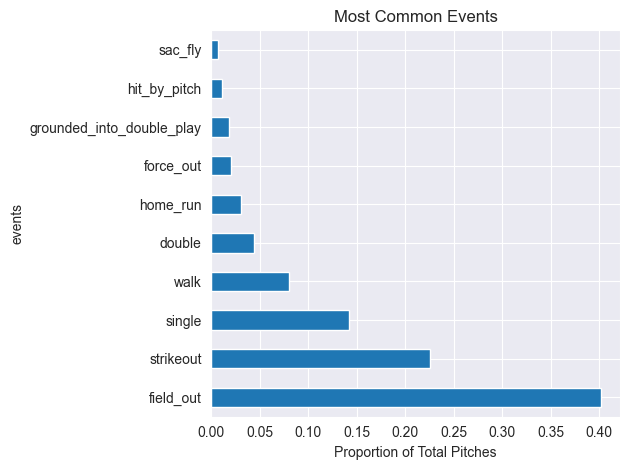

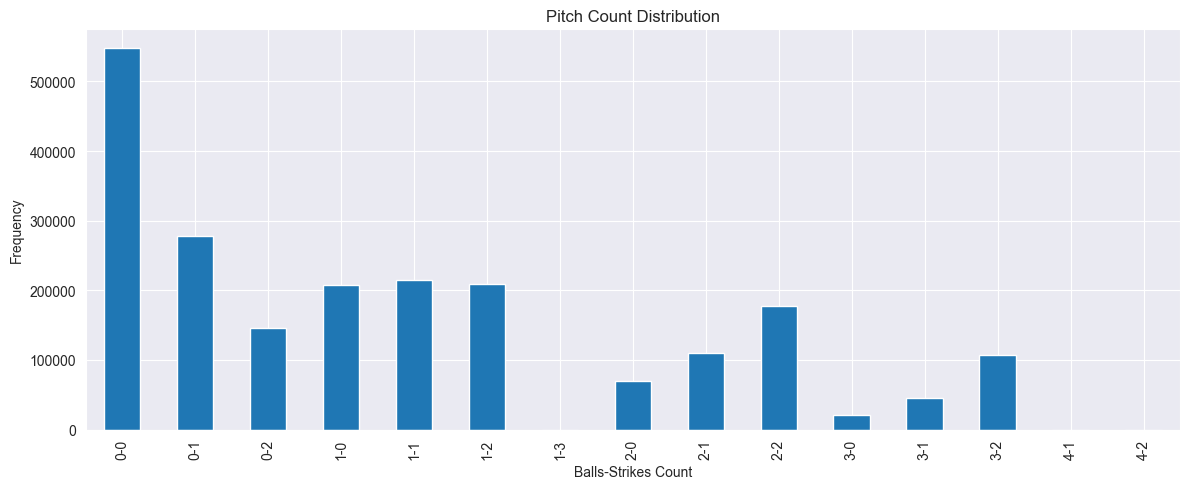

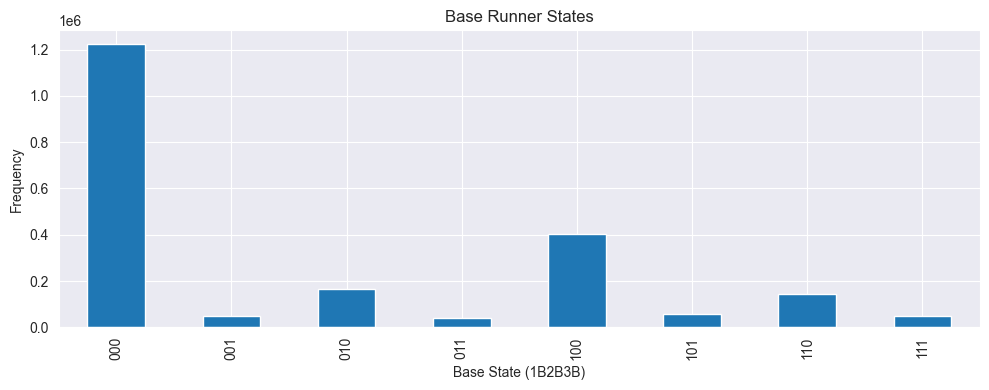

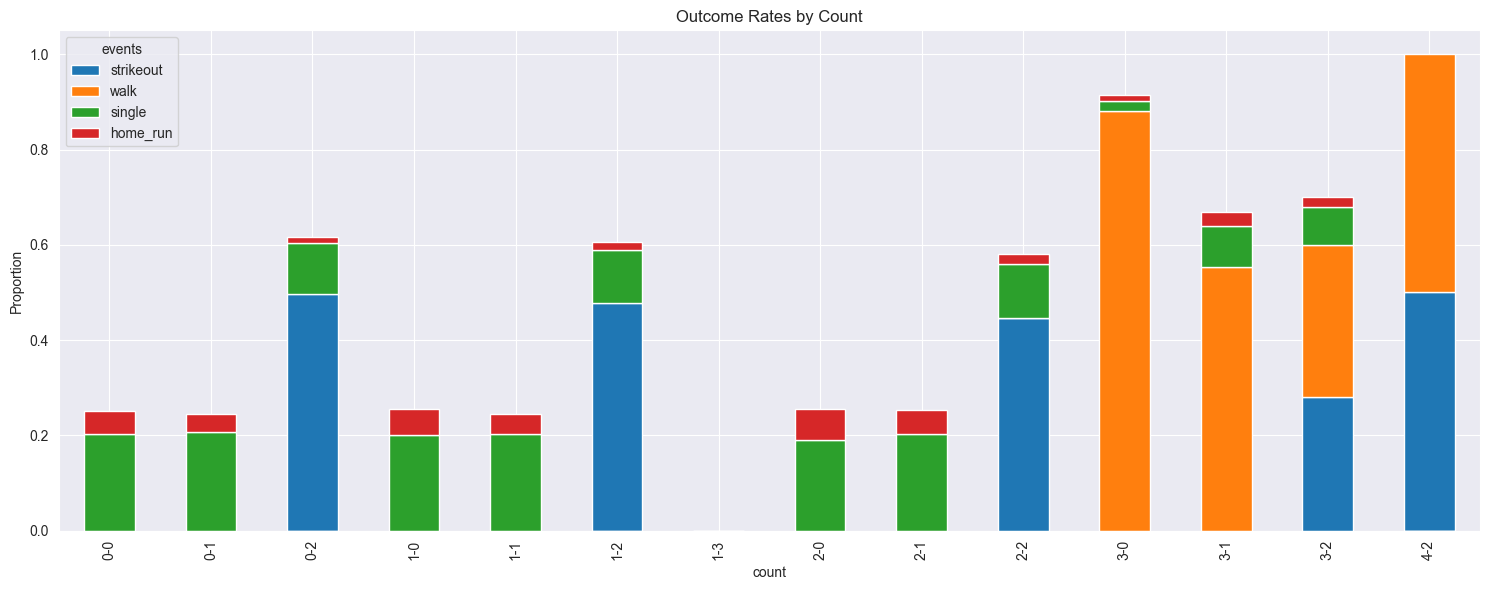

In [1]:
# EDA Summary for Statcast Dataset (2022–2024)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load merged dataset
data_path = "/Users/joshsteckler/PycharmProjects/baseball-mvp/situation_game_probability/data/merged_statcast_2022_2024.csv"
df = pd.read_csv(data_path)

# --- Basic Inspection ---
print("Shape:", df.shape)
print("\nMissing Values (Top 15):")
print(df.isna().mean().sort_values(ascending=False).head(15))

# Convert and clean fields
df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")
for col in ["stand", "p_throws", "inning_topbot"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.upper()

# --- Unique Pitchers and Batters ---
print("\nUnique Pitchers:", df['pitcher_id'].nunique())
print("Unique Batters:", df['batter_id'].nunique())

# --- Count Column (if missing) ---
if 'count' not in df.columns and {'balls', 'strikes'}.issubset(df.columns):
    df['count'] = df['balls'].astype(str) + "-" + df['strikes'].astype(str)

# --- Base State Column ---
if all(col in df.columns for col in ['on_1b', 'on_2b', 'on_3b']):
    df['base_state'] = df.apply(
        lambda row: f"{int(pd.notna(row.on_1b))}{int(pd.notna(row.on_2b))}{int(pd.notna(row.on_3b))}", axis=1
    )

# --- Event Distribution ---
print("\nTop 10 Events:")
print(df['events'].value_counts(normalize=True).head(10))

df['events'].value_counts(normalize=True).head(10).plot(kind='barh', title='Most Common Events')
plt.xlabel("Proportion of Total Pitches")
plt.tight_layout()
plt.show()

# --- Count Distribution ---
if 'count' in df.columns:
    df['count'].value_counts().sort_index().plot(kind='bar', figsize=(12, 5), title='Pitch Count Distribution')
    plt.xlabel("Balls-Strikes Count")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# --- Base State Distribution ---
if 'base_state' in df.columns:
    df['base_state'].value_counts().sort_index().plot(kind='bar', figsize=(10, 4), title='Base Runner States')
    plt.xlabel("Base State (1B2B3B)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# --- Advanced (Optional): Outcome by Count ---
if 'count' in df.columns:
    outcome_by_count = df.groupby('count')['events'].value_counts(normalize=True).unstack().fillna(0)
    outcome_subset = outcome_by_count[['strikeout', 'walk', 'single', 'home_run']] \
                        if all(col in outcome_by_count.columns for col in ['strikeout', 'walk', 'single', 'home_run']) \
                        else outcome_by_count.iloc[:, :4]
    outcome_subset.plot(kind='bar', stacked=True, figsize=(15, 6), title='Outcome Rates by Count')
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.show()
